머신러닝 - 분류 (붓꽃 예제)

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [70]:
import pandas as pd
iris = load_iris()
iris_data = iris.data
iris_label = iris.target
print('iris target값:', iris_label)
print('iris target명:', iris.target_names)
iris_df = pd.DataFrame(data=iris_data, columns = iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label,

test_size = 0.2, random_state = 11)

print(X_train[0])

[5.1 3.5 1.4 0.2]


In [ ]:
# 학습 / 예측
dt_clf = DecisionTreeClassifier(random_state = 11)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)

# 평가
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, pred)
print('예측 정확도: {0:.4f}'.format(acc))

예측 정확도: 0.9333


머신러닝 - 분류

In [5]:
import numpy as np
from sklearn.base import BaseEstimator
class MyDummyClassifier(BaseEstimator):
# 남성이면 사망, 여성이면 생존으로 예측하는 모델
    def fit(self, X, y = None):
        pass
    # 실제 데이터에서 남자->사망, 여자->생존이 아닌데 predict함수에서 사람이 정해놓은 규칙이 있음
    # 사실상 더미 함수는 이 코드에서 활용되지 않음
    def predict(self, X):
        pred = np.zeros((X.shape[0], 1))
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i] == 'male':
                pred[i] = 0
            else:
                pred[i] = 1
        return pred

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

titanic_df = pd.read_csv('data/titanic.csv')

y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df,

test_size = 0.2, random_state = 0)

In [7]:
# 생성한 모델을 사용하여 학습/예측/평가
myclf = MyDummyClassifier()
myclf.fit(X_train, y_train)
mypredictions = myclf.predict(X_test)
print('정확도 :', accuracy_score(y_test, mypredictions))

정확도 : 0.7877094972067039


In [8]:
model= MyDummyClassifier()
model.predict(X_test)

array([[0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],

In [9]:
from sklearn.datasets import load_digits

digits = load_digits()
# digits 데이터셋은 손글씨 숫자(0~9)를 8x8 크기의 아주 작은 흑백 이미지로 스캔해서 만든 데이터
row = digits.data[0] # 인덱스를 바꾸면 출력되는 배열, 출력되는 이미지의 숫자가 달라짐
print(row.reshape(8,8))

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


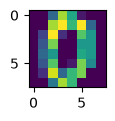

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(1,1))
plt.imshow(row.reshape(8,8))

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 0)

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

print('정확도 : ', accuracy_score(y_test, pred))
print('오차행렬 : ', confusion_matrix(y_test, pred))
# 오차행렬: [[TN, FP], [FN, TP]] 순서로 출력됨
# 44: TN(암인데 암으로 예측), 60: TF
# FN(7)이 FP(3)보다 크기 때문에, FN이 분모에 들어가는 재현율이 정밀도보다 더 낮게(안 좋게) 나옴
# predict는 1로 예측(정상 기준)

print('정밀도 : ', precision_score(y_test, pred))
print('재현율 : ', recall_score(y_test, pred))

정확도 :  0.9122807017543859
오차행렬 :  [[44  3]
 [ 7 60]]
정밀도 :  0.9523809523809523
재현율 :  0.8955223880597015


In [13]:
cancer.target_names
# (0,1) = (암, 정상)
# 0이 암, 1이 정상 -> FN이 가장 위험한 경우

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
dt_clf.predict_proba(X_test)
# 확률이 0.5보다 크면 1, 작으면 0 (임계값 0.5)

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.

In [ ]:
# 선형회귀 모델 중 로지스틱 회귀 모델 추가
from sklearn.linear_model import LogisticRegression

# lr : 로지스틱 회귀(Logistic Regression)
# clf : 분류기(Classifier)

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)

c:\Users\rlawjdgns213\Documents\GitHub\Samsung_Heavy_Industry_AI_Specialist_Education\데이터분석_Advanced\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
print('정확도 : ', accuracy_score(y_test, pred))
print('오차행렬 : ', confusion_matrix(y_test, pred))
print('정밀도 : ', precision_score(y_test, pred))
print('재현율 : ', recall_score(y_test, pred))

정확도 :  0.956140350877193
오차행렬 :  [[46  1]
 [ 4 63]]
정밀도 :  0.984375
재현율 :  0.9402985074626866


In [ ]:
from sklearn.preprocessing import Binarizer

X = [[ 1, -1, 2],
[ 2, 0, 0],
[ 0, 1.1, 1.2]]
binarizer = Binarizer(threshold= 1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [20]:
(np.array(X) > 1.1).astype(int)

array([[0, 0, 1],
       [1, 0, 0],
       [0, 0, 1]])

In [ ]:
# pred_proba의 첫번째 열의 값이 0.5보다 큰 것만 가져와서 pred2에 저장
# pred와 pred2를 비교하면 정확도 100%
# 왜? pred는 뭐고, pred2는 뭐길래
# -> 
pred2 = pred_proba[:, 1] > 0.5
accuracy_score(pred, pred2)

1.0

In [ ]:
# 임계값을 0.4로 지정 (아직 이유 없음)
custom_threshold = 0.4

# 전체 행, 첫 번째 열에 있는 값을 전부 들고 와서 pred_proba_1로 저장
pred_proba_1 = pred_proba[:,1].reshape(-1,1)

# 이진 분류 모델 지정(임계값 지정)하고 학습(학습 데이터)
binarizer = Binarizer(threshold = custom_threshold ).fit(pred_proba_1)

#
custom_predict = binarizer.transform(pred_proba_1)


In [23]:
pred_proba[:, 1]

array([5.77388685e-03, 9.75308618e-01, 9.98448679e-01, 8.27839640e-01,
       9.99918920e-01, 9.97955885e-01, 9.94526951e-01, 9.98382143e-01,
       9.80335283e-01, 9.99717872e-01, 5.10861744e-01, 8.89717350e-01,
       9.96897396e-01, 1.43627781e-01, 8.26203418e-01, 5.91567897e-03,
       9.89602888e-01, 1.08557435e-09, 8.26312204e-04, 1.06294676e-12,
       1.32302948e-05, 9.74907016e-02, 9.98886299e-01, 9.91026804e-01,
       6.34775318e-03, 9.82463317e-01, 9.98151477e-01, 1.58448419e-01,
       9.97864770e-01, 7.52591059e-12, 9.99673678e-01, 1.43071218e-08,
       6.79575327e-01, 3.17695155e-04, 9.99867430e-01, 1.28252857e-03,
       9.17116607e-01, 9.06461053e-07, 9.97442662e-01, 2.52665681e-04,
       7.19532848e-02, 9.97430414e-01, 1.46433140e-03, 9.99267300e-01,
       6.05300723e-02, 2.00397529e-13, 9.99798003e-01, 9.67874958e-01,
       9.98171209e-01, 3.01483298e-04, 1.59652011e-06, 4.13202596e-01,
       2.27078466e-07, 9.96840121e-01, 9.94393291e-01, 9.99287190e-01,
      

In [29]:
# pred의 평가 점수들
print('임계값 0.5')
print('정확도 : ', accuracy_score(y_test, pred))
print('오차행렬 : ', confusion_matrix(y_test, pred))
print('정밀도 : ', precision_score(y_test, pred))
print('재현율 : ', recall_score(y_test, pred))


# # pred2의 평가 점수들 (0.4)
# pred2 = pred_proba[:, 1] > 0.4
# print('임계값 0.4')
# print('정확도 : ', accuracy_score(y_test, pred2))
# print('오차행렬 : ', confusion_matrix(y_test, pred2))
# print('정밀도 : ', precision_score(y_test, pred2))
# print('재현율 : ', recall_score(y_test, pred2))


# # pred2의 평가 점수들
# pred2 = pred_proba[:, 1] > 0.6
# print('임계값 0.6')
# print('정확도 : ', accuracy_score(y_test, pred2))
# print('오차행렬 : ', confusion_matrix(y_test, pred2))
# print('정밀도 : ', precision_score(y_test, pred2))
# print('재현율 : ', recall_score(y_test, pred2))


# pred2의 평가 점수들
pred2 = pred_proba[:, 1] > 0.7
print('임계값 0.7')
print('정확도 : ', accuracy_score(y_test, pred2))
print('오차행렬 : ', confusion_matrix(y_test, pred2))
print('정밀도 : ', precision_score(y_test, pred2))
print('재현율 : ', recall_score(y_test, pred2))


# pred2의 평가 점수들
# 임계값을 줄인다는 것은 재현율을 올린다는 의미
pred2 = pred_proba[:, 1] > 0.3
print('임계값 0.3')
print('정확도 : ', accuracy_score(y_test, pred2))
print('오차행렬 : ', confusion_matrix(y_test, pred2))
print('정밀도 : ', precision_score(y_test, pred2))
print('재현율 : ', recall_score(y_test, pred2))

# 임계값 조절을 통해 오차행렬의 점수를 바꿀 수 있음.
# 한 쪽이 증가하면 한 쪽이 

임계값 0.5
정확도 :  0.956140350877193
오차행렬 :  [[46  1]
 [ 4 63]]
정밀도 :  0.984375
재현율 :  0.9402985074626866
임계값 0.7
정확도 :  0.9385964912280702
오차행렬 :  [[46  1]
 [ 6 61]]
정밀도 :  0.9838709677419355
재현율 :  0.9104477611940298
임계값 0.3
정확도 :  0.956140350877193
오차행렬 :  [[44  3]
 [ 2 65]]
정밀도 :  0.9558823529411765
재현율 :  0.9701492537313433


In [30]:
# precision_recall_curve : 정밀도와 재현율의 트레이드오프 관계를 그려주는 그래프
from sklearn.metrics import precision_recall_curve
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1 )

print('반환된 분류 결정 임곗값 배열의 Shape:', thresholds.shape)
print('반환된 precisions 배열의 Shape:', precisions.shape)
print('반환된 recalls 배열의 Shape:', recalls.shape)
print("thresholds 5 sample:", thresholds[:5])
print("precisions 5 sample:", precisions[:5])
print("recalls 5 sample:", recalls[:5])

반환된 분류 결정 임곗값 배열의 Shape: (114,)
반환된 precisions 배열의 Shape: (115,)
반환된 recalls 배열의 Shape: (115,)
thresholds 5 sample: [5.74310419e-20 1.95442378e-18 4.13747771e-17 2.00397529e-13
 1.06294676e-12]
precisions 5 sample: [0.5877193  0.59292035 0.59821429 0.6036036  0.60909091]
recalls 5 sample: [1. 1. 1. 1. 1.]


In [ ]:
from sklearn.metrics import f1_score

# 정밀도 : 0.984375
# 재현율 : 0.9402985074626866
print(f1_score(y_test, pred))

0.9618320610687023


In [35]:
pred2 = pred_proba[:, 1] > 0.5
print('임계값 0.5')
print('오차행렬 :', confusion_matrix(y_test, pred2))
print('F1 : ', f1_score(y_test, pred2))
print()

pred2 = pred_proba[:, 1] > 0.3
print('임계값 0.3')
print('오차행렬 :', confusion_matrix(y_test, pred2))
print('F1 : ', f1_score(y_test, pred2))

임계값 0.5
오차행렬 : [[46  1]
 [ 4 63]]
F1 :  0.9618320610687023

임계값 0.3
오차행렬 : [[44  3]
 [ 2 65]]
F1 :  0.9629629629629629


In [43]:
pred2 = pred_proba[:, 1] > 0.00005
print('오차행렬 :', confusion_matrix(y_test, pred2))

오차행렬 : [[25 22]
 [ 0 67]]


In [37]:
pred_proba

array([[9.94226113e-01, 5.77388685e-03],
       [2.46913821e-02, 9.75308618e-01],
       [1.55132100e-03, 9.98448679e-01],
       [1.72160360e-01, 8.27839640e-01],
       [8.10800930e-05, 9.99918920e-01],
       [2.04411544e-03, 9.97955885e-01],
       [5.47304869e-03, 9.94526951e-01],
       [1.61785651e-03, 9.98382143e-01],
       [1.96647167e-02, 9.80335283e-01],
       [2.82127663e-04, 9.99717872e-01],
       [4.89138256e-01, 5.10861744e-01],
       [1.10282650e-01, 8.89717350e-01],
       [3.10260375e-03, 9.96897396e-01],
       [8.56372219e-01, 1.43627781e-01],
       [1.73796582e-01, 8.26203418e-01],
       [9.94084321e-01, 5.91567897e-03],
       [1.03971125e-02, 9.89602888e-01],
       [9.99999999e-01, 1.08557435e-09],
       [9.99173688e-01, 8.26312204e-04],
       [1.00000000e+00, 1.06294676e-12],
       [9.99986770e-01, 1.32302948e-05],
       [9.02509298e-01, 9.74907016e-02],
       [1.11370126e-03, 9.98886299e-01],
       [8.97319612e-03, 9.91026804e-01],
       [9.936522

In [48]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, pred_proba[:, 1])

0.9926960939980947

In [49]:
# 분류(Classification) 평가 지표
# 정확도, 오차행렬, 정밀도, 재현율, F1스코어, ROC_AUC
# 정확도 : 모델의 가장 기본적인 평가 기준(제일 쉬움), 모델이 정답을 얼마나 잘 맞추는지
# 오차행렬 : 정답을 어떻게 예측해서 맞추고 틀렸는지를 표현
# 정밀도 : 예측을 positive > 얼마나 맞췄냐

# 재현율 : 실제값이 positive > 얼마나 맞췄냐
# -> 임계값 조정 통해서 정밀도나 재현율의 값을 올리거나 내리거나 할 수 있다.

# F1스코어 : 정밀도, 재현율이 밸런스 있게 높은 점수가 나오는지

# ROC_AUC : 분류 임계값과 무관한 클래스 구분 능력
# -> ROC_AUC만 predict_proba의 확률값을 넣어서 계산

In [57]:
# 와인 데이터셋

from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["class"] = wine.target
print(wine.target_names)
df.head()

['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [52]:
from sklearn.model_selection import train_test_split

X_data = df.iloc[:, :-1]
y_data = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=156
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(142, 13) (36, 13)
(142,) (36,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print("결정 트리 예측 정확도: {0:.4f}".format(accuracy))

결정 트리 예측 정확도: 0.9444


In [56]:
# 오차행렬
confusion_matrix(y_test, pred)

array([[11,  0,  0],
       [ 1, 12,  1],
       [ 0,  0, 11]])

In [58]:
from sklearn.metrics import precision_score

# precision_score : 정밀도
# average 속성 : 
# micro : 전체 클래스에 대한 정밀도 계산
precision_score(y_test, pred, average="micro")

0.9444444444444444

In [59]:
print(precision_score(y_test, pred, average="micro"))
print(recall_score(y_test, pred, average="micro"))
print(f1_score(y_test, pred, average="micro"))

0.9444444444444444
0.9444444444444444
0.9444444444444444


In [ ]:
pred_proba = dt_clf.predict_proba(X_test)

# 다중 분류에서 [:, 1]를 사용하지 않는 이유
# -> 전체 확률을 가져와야 하기 때문에

# multi_class 속성 : 다중 분류에서 ROC_AUC를 계산할 때, OvR(One-vs-Rest) 방식과 OVO(One-vs-One) 방식 중 선택
roc_auc_score(y_test, pred_proba, multi_class="ovo")

np.float64(0.9642857142857143)

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.86      0.92        14
           2       0.92      1.00      0.96        11

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.95        36
weighted avg       0.95      0.94      0.94        36



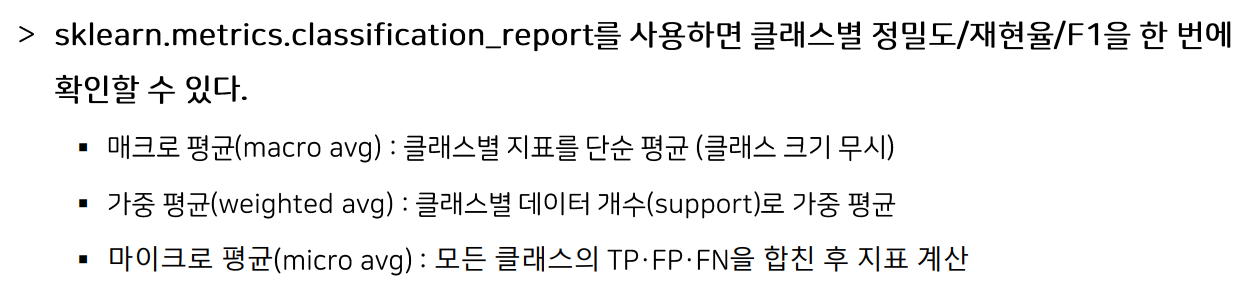

In [ ]:
# macro : 클래스별 지표를 단순 평균
(0.92 + 1.00 + 0.92) / 3

# weighted : 클래스별 데이터 개수로 가중(weighted) 평균
((11/36)*0.92 + (14/36)*1.00 + (11/36)*0.92) / 3

# micro : 모든 클래스의 TP, FP, FN을 합친 후 지표 계산


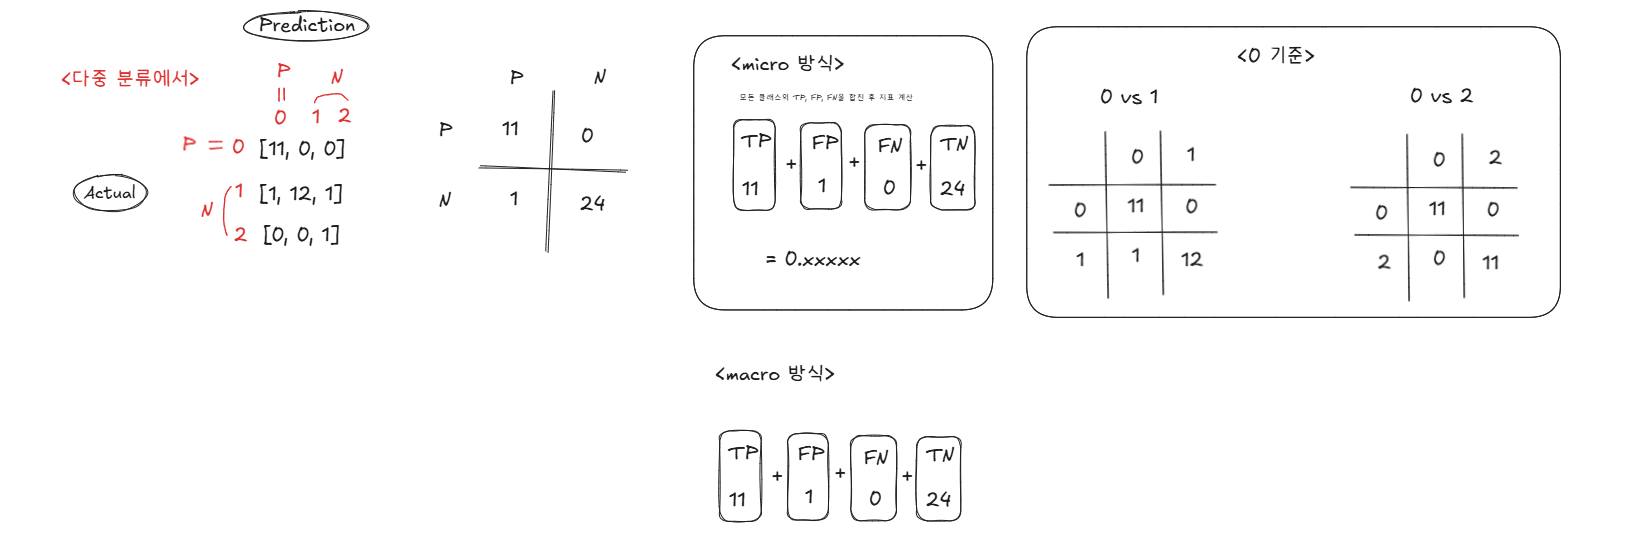

In [64]:
# OVO : one vs one
# OVR : one vs rest

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

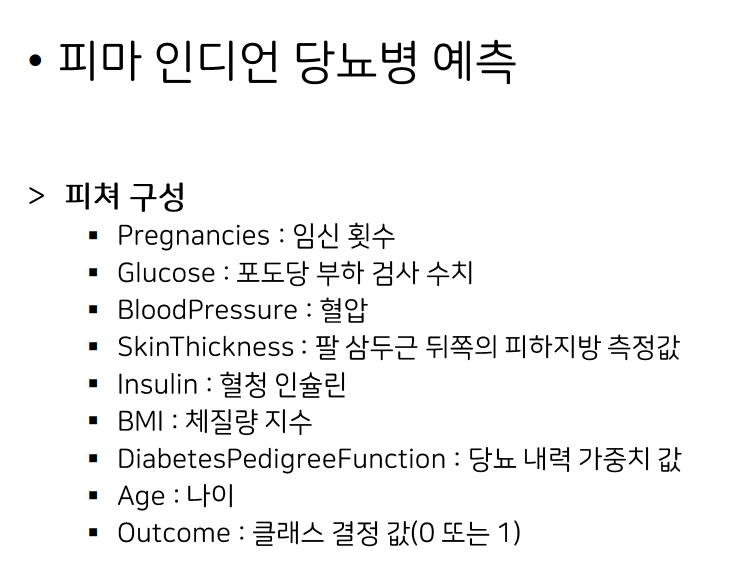

In [67]:
diabetes = pd.read_csv("data/diabetes.csv")
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [68]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [69]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# 임신 횟수(Pregnancies)가 3.4회 -> 많다.
# 포도당 부하 검사 수치(Glucose) 최저값 0 -> 이상함.
# 혈압 최저값(BloodPressure) 0 -> 죽은 사람.
# 피하지방(SkinThickness) 최저값 0 -> 이상하지만 불가능하지는 않다.
# 인슐린(Insulin) 평균 80, 표준편차 115 -> 이상함. 0이 많음을 의미

# 임신 횟수 제외한 나머지 0값들은 이상치로 판단하고 처리할 필요가 있다.


In [71]:
# 모든 행의 마지막 컬럼 전까지를 독립변수로 지정
X = diabetes.iloc[:, :-1]

# 마지막 컬럼을 종속변수로 지정
y = diabetes.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=156, stratify=y
)

lr_clf = LogisticRegression(solver="liblinear")
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

In [72]:
y_test.value_counts()

Outcome
0    100
1     54
Name: count, dtype: int64

In [73]:
lr_clf = LogisticRegression(solver="liblinear")
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

In [74]:
accuracy = accuracy_score(y_test , pred)
confusion = confusion_matrix(y_test, pred)
precision = precision_score(y_test , pred)
recall = recall_score(y_test , pred)
f1 = f1_score(y_test, pred)
roc = roc_auc_score(y_test, pred_proba)
print('오차 행렬')
print(confusion)
print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, ROC_AUC: {roc:.4f}')

오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926, F1: 0.6465, ROC_AUC: 0.8083


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 분류 모델 지정 (의사결정나무)
dt_clf = DecisionTreeClassifier()

# 모델 학습(학습데이터_독립변수, 학습데이터_종속변수)
dt_clf.fit(X_train, y_train)

# 예측한 결과 저장
pred = dt_clf.predict(X_test)
pred_proba = dt_clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test , pred)
confusion = confusion_matrix(y_test, pred)
precision = precision_score(y_test , pred)
recall = recall_score(y_test , pred)
f1 = f1_score(y_test, pred)
roc = roc_auc_score(y_test, pred_proba)
print('오차 행렬')
print(confusion)
print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, ROC_AUC: {roc:.4f}')

오차 행렬
[[81 19]
 [24 30]]
정확도: 0.7208, 정밀도: 0.6122, 재현율: 0.5556, F1: 0.5825, ROC_AUC: 0.6828


In [77]:
from sklearn.ensemble import RandomForestClassifier

# 분류 모델 지정 (의사결정나무)
rf_clf = DecisionTreeClassifier()

# 모델 학습(학습데이터_독립변수, 학습데이터_종속변수)
rf_clf.fit(X_train, y_train)

# 예측한 결과 저장
pred = rf_clf.predict(X_test)
pred_proba = rf_clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test , pred)
confusion = confusion_matrix(y_test, pred)
precision = precision_score(y_test , pred)
recall = recall_score(y_test , pred)
f1 = f1_score(y_test, pred)
roc = roc_auc_score(y_test, pred_proba)
print('오차 행렬')
print(confusion)
print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, ROC_AUC: {roc:.4f}')

오차 행렬
[[81 19]
 [27 27]]
정확도: 0.7013, 정밀도: 0.5870, 재현율: 0.5000, F1: 0.5400, ROC_AUC: 0.6550


## 로지스틱 회귀분석 (분류) (스케일링 영향 O)
오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926, F1: 0.6465, ROC_AUC: 0.8083

## 의사결정나무 (스케일링 영향 X)
오차 행렬
[[81 19]
 [24 30]]
정확도: 0.7208, 정밀도: 0.6122, 재현율: 0.5556, F1: 0.5825, ROC_AUC: 0.6828

## 랜덤포레스트 (스케일링 영향 X)
오차 행렬
[[81 19]
 [27 27]]
정확도: 0.7013, 정밀도: 0.5870, 재현율: 0.5000, F1: 0.5400, ROC_AUC: 0.6550